In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [25]:
!pip install squarify

In [26]:
import squarify

In [27]:
df = pd.read_csv("Iris.csv")

In [28]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [29]:
df.shape

(150, 6)

In [30]:
df.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [31]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [33]:
df.duplicated().sum()

0

In [34]:
df = df.drop(columns = 'Id')

In [36]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


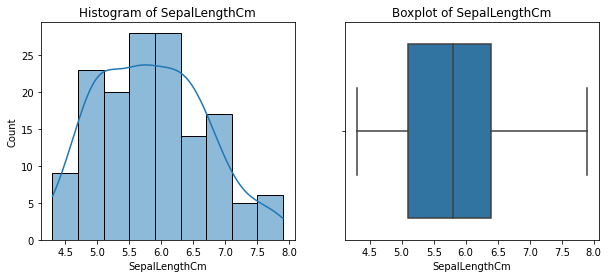

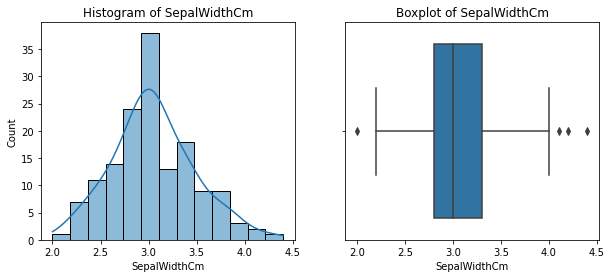

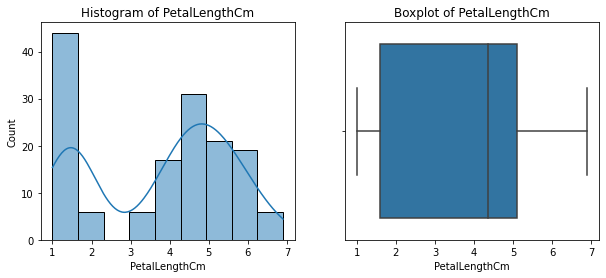

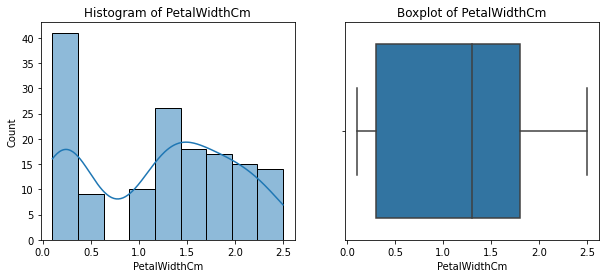

In [35]:
##Histogram and Boxplot
for col in df.select_dtypes(include='number').columns:
    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Histogram of {col}')

    plt.subplot(1,2,2)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')

    plt.show()

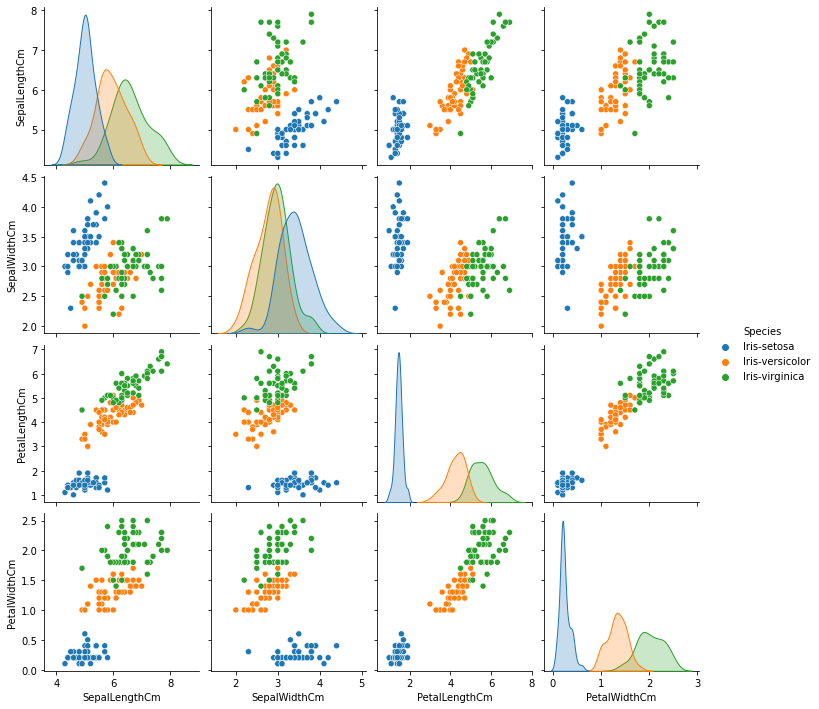

In [38]:
#Scatter plots
sns.pairplot(df, hue='Species')
plt.show()

In [40]:
# Treemap (for species count)
species_counts = df['Species'].value_counts()    #Counts number of rows per species
species_counts

Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: Species, dtype: int64

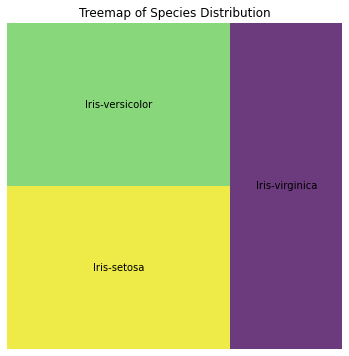

In [41]:
plt.figure(figsize=(6,6))
squarify.plot(
    sizes=species_counts.values, #rectangle size
    label=species_counts.index, # category name
    alpha=0.8 # transparency
)
plt.title("Treemap of Species Distribution")
plt.axis('off') #removes axes
plt.show()

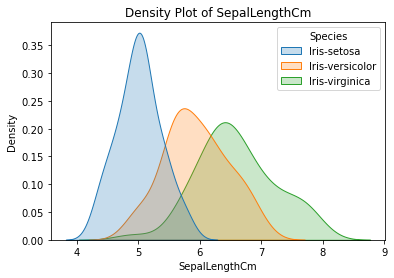

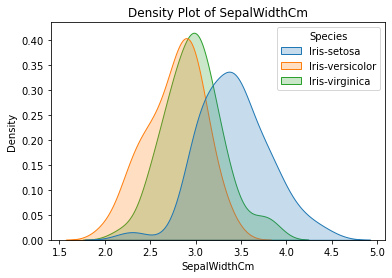

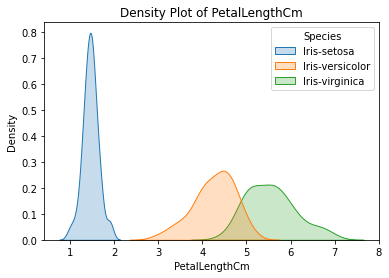

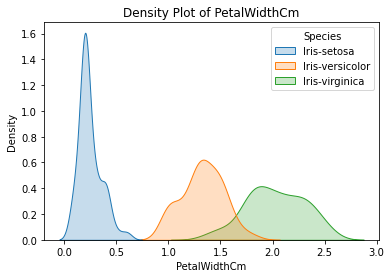

In [43]:
#  Density Plots                              # Compare distributions across categories
for col in df.select_dtypes(include='number').columns:
    plt.figure()
    sns.kdeplot(data=df, x=col, hue='Species', fill=True) #Smooth probability distribution, Separate curve for each species
    plt.title(f'Density Plot of {col}')
    plt.show()

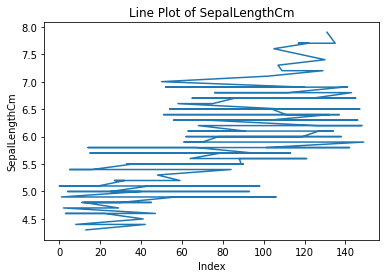

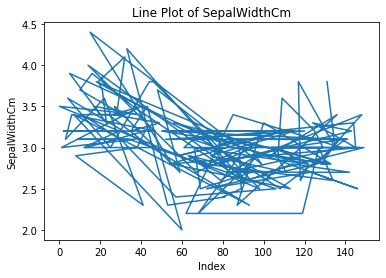

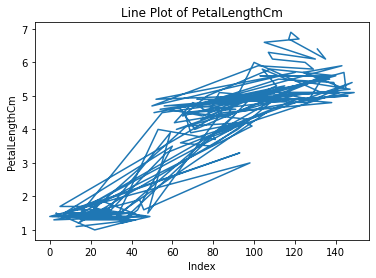

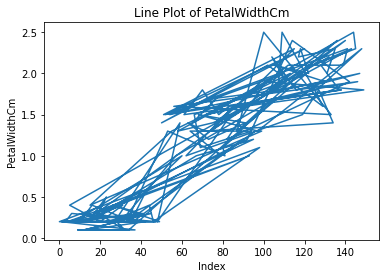

In [45]:
# Line Plots

df_sorted = df.sort_values(by='SepalLengthCm') #sorts dataset

for col in df.select_dtypes(include='number').columns:
    plt.figure()
    plt.plot(df_sorted[col])
    plt.title(f'Line Plot of {col}')
    plt.xlabel('Index')
    plt.ylabel(col)
    plt.show()